In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_parquet(
    r"C:\Users\usuario\Desktop\data_ingestion\df_filtered.parquet"
)

In [172]:
df_artigo = df[[
    "cusip",
    "issuer_cusip",
    "date",
    "cs",
    "dcs6",
    "es_90",
    "cs_mu12_1",
    "spc_rat",
    "tmat",
    "md_dur",
    "convx",
    "age",
    "sze",
    "ami",
    "spd_rel",
    "roll",
    "b_dvix",
    "sig_dt",
    "ff30num",
    "mdc_rat",
    "ret_vw",
    "val_hz",
    "lix",
    "call",
    "dvol",
    "var_95",
    "b_mktb_mkt",
    "b_cptlt",
    "b_duncf",
    "b_dunc",
    "b_epu",
    "b_dcpi",
    "b_unc",
    "b_crf",
    "val_hz_dts"
]].rename(columns={
    "cusip": "bond_id",
    "issuer_cusip": "issuer_id",
    "date": "date",
    "cs": "credit_spread",
    "es_90": "expected_shortfall",
    "spc_rat": "sp_rating",
    "md_dur": "duration",
    "age": "bond_age",
    "sze": "bond_size",
    "ami": "amihud_illiquidity",
    "spd_rel": "relative_spread",
    "roll": "roll_spread",
    "b_dvix": "vix_beta",
    "sig_dt": "signal_date",
    "ff30num": "industry_ff30",
    "mdc_rat": "mdc_rating",
    "ret_vw": "return",
    "dcs6": "var_spread_6m",
    "cs_mu12_1": "spread_movel_12m",
    "val_hz": "Spread_justo",
    "val_hz_dts" :"Spread_justo_adj",
    "lix": "liquid_lix",
    "dvol": "vol_diaria",
    "var_95": "var_95",
    "call": "call",
    "b_mktb_mkt": "b_mktb_mkt",
    "b_cptlt": "b_cptlt",
    "b_duncf": "b_duncf",
    "b_dunc": "b_dunc",
    "b_epu": "b_epu",
    "b_dcpi": "b_dcpi",
    "b_unc": "b_unc",
    "b_crf": "b_crf"
})

In [19]:
ff17_dict = {
    1: "Food",
    2: "Mining and Minerals",
    3: "Oil and Petroleum Products",
    4: "Textiles, Apparel & Footwear",
    5: "Consumer Durables",
    6: "Chemicals",
    7: "Drugs, Soap, Perfumes & Tobacco",
    8: "Construction & Construction Materials",
    9: "Steel Works",
    10: "Fabricated Products",
    11: "Machinery & Business Equipment",
    12: "Automobiles",
    13: "Transportation",
    14: "Utilities",
    15: "Retail Stores",
    16: "Financials",
    17: "Other"
}

In [173]:
titulos_por_data = (
    df.groupby("date")["cusip"]
      .nunique()
      .reset_index(name="n_titulos")
)

print(f"Média de títulos por mês: {titulos_por_data['n_titulos'].mean():,.0f}")
print(f"Mediana: {titulos_por_data['n_titulos'].median():,.0f}")
print(f"Mínimo: {titulos_por_data['n_titulos'].min():,.0f}")
print(f"Máximo: {titulos_por_data['n_titulos'].max():,.0f}")

Média de títulos por mês: 6,775
Mediana: 6,720
Mínimo: 4,279
Máximo: 9,555


In [33]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"Observações: {len(df_artigo):,}")
print(f"Variáveis: {len(df_artigo.columns):,}")

print("\nTipos das variáveis:")
print(df_artigo.dtypes)

DATASET OVERVIEW
Observações: 1,239,851
Variáveis: 35

Tipos das variáveis:
bond_id                     category
issuer_id                   category
date                          object
credit_spread                float32
var_spread_6m                float32
expected_shortfall           float64
spread_movel_12m             float64
sp_rating                      int32
maturity                     float32
duration                     float32
convexity                    float32
bond_age                     float32
bond_size                    float32
amihud_illiquidity           float32
relative_spread              float64
roll_spread                  float32
vix_beta                     float64
signal_date           datetime64[ns]
industry_ff30                   Int8
mdc_rating                     int32
return                       float32
Spread_justo                 float32
liquid_lix                   float32
call                            int8
vol_diaria                   float64

Valores Nulos ou Vazios

In [83]:

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)

missing = pd.DataFrame({
    "missing_count": df_artigo.isnull().sum(),
    "missing_pct": (
        df_artigo.isnull().sum()
        / len(df_artigo)
        * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

print(missing)



MISSING VALUES
                    missing_count  missing_pct
b_dcpi                     243809        19.66
b_epu                      243809        19.66
b_dunc                     243809        19.66
vix_beta                   243809        19.66
b_duncf                    243809        19.66
b_unc                      243809        19.66
b_term_dcapm               243809        19.66
b_mktb_mkt                 243809        19.66
b_crf                      243809        19.66
expected_shortfall         219935        17.74
var_95                     219935        17.74
b_cptlt                    219935        17.74
var_spread_6m              184693        14.90
spread_movel_12m           179039        14.44
roll_spread                172622        13.92
Spread_justo               171555        13.84
Spread_justo_adj           171555        13.84
liquid_lix                 146751        11.84
amihud_illiquidity         144794        11.68
vol_diaria                 144794        11

In [174]:
df_model2 = df_artigo.dropna(
    subset=["vix_beta","roll_spread","b_dunc","var_spread_6m","liquid_lix"]
).copy()

In [175]:
df_model = df_model2[
    [
        "bond_id",
        "issuer_id",
        "date",
        "credit_spread",            # variável dependente 1
        "Spread_justo_adj",          # variável dependente 2
        "amihud_illiquidity",
        "var_spread_6m",
        "return",
        "vix_beta",
        "industry_ff30",
        "bond_age",
        "bond_size",
        "vol_diaria",
        "duration",
        "liquid_lix",
        "expected_shortfall",
        "var_95",
        "roll_spread",
        "b_mktb_mkt",
        "b_cptlt",
        "b_duncf",
        "b_dunc",
        "b_epu",
        "b_dcpi",
        "b_unc",
        "b_crf",
        "spread_movel_12m",
        "Spread_justo"
    ]
].copy()

In [176]:

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)

missing = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_pct": (
        df_model.isnull().sum()
        / len(df_model)
        * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

print(missing)



MISSING VALUES
                    missing_count  missing_pct
bond_id                         0          0.0
issuer_id                       0          0.0
date                            0          0.0
credit_spread                   0          0.0
Spread_justo_adj                0          0.0
amihud_illiquidity              0          0.0
var_spread_6m                   0          0.0
return                          0          0.0
vix_beta                        0          0.0
industry_ff30                   0          0.0
bond_age                        0          0.0
bond_size                       0          0.0
vol_diaria                      0          0.0
duration                        0          0.0
liquid_lix                      0          0.0
expected_shortfall              0          0.0
var_95                          0          0.0
roll_spread                     0          0.0
b_mktb_mkt                      0          0.0
b_cptlt                         0          

In [124]:
print(f"Obs originais: {len(df_artigo):,}")
print(f"Obs finais:    {len(df_model):,}")

print(
    f"Perda (%): "
    f"{100*(1-len(df_model)/len(df_artigo)):.2f}"
)

Obs originais: 1,239,851
Obs finais:    852,634
Perda (%): 31.23


In [125]:
print("Amostra Final")

print(
    "Títulos:",
    df_model["bond_id"].nunique()
)

print(
    "Emissores:",
    df_model["issuer_id"].nunique()
)

print(
    "Observações:",
    len(df_model)
)

print(
    "Período:",
    df_model["date"].min(),
    "até",
    df_model["date"].max()
)

Amostra Final
Títulos: 22739
Emissores: 3823
Observações: 852634
Período: 2010-01-31 até 2024-12-31


Variáveis do Modelo

In [177]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

In [178]:
print("\n")
print("="*80)
print("OUTLIER CHECK")
print("="*80)

outlier_report = []

numeric_cols = df_model.select_dtypes(
    include=["number"]
).columns

for col in numeric_cols:

    q1 = df_model[col].quantile(.25)
    q3 = df_model[col].quantile(.75)

    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outliers = (
        (df_model[col] < lower)
        |
        (df_model[col] > upper)
    ).sum()

    outlier_report.append([
        col,
        outliers,
        round(
            outliers
            /
            len(df_model)
            *100,
            2
        )
    ])

outlier_report = pd.DataFrame(
    outlier_report,
    columns=[
        "variable",
        "outliers",
        "pct_outliers"
    ]
)

print(
    outlier_report.sort_values(
        "pct_outliers",
        ascending=False
    )
)




OUTLIER CHECK
              variable  outliers  pct_outliers
21               b_unc    127769         14.99
19               b_epu    103550         12.14
4               return    101072         11.85
2   amihud_illiquidity    100915         11.84
18              b_dunc     98198         11.52
5             vix_beta     95983         11.26
20              b_dcpi     89626         10.51
22               b_crf     85524         10.03
17             b_duncf     80362          9.43
0        credit_spread     72536          8.51
23    spread_movel_12m     69881          8.20
8            bond_size     59935          7.03
7             bond_age     59355          6.96
16             b_cptlt     57836          6.78
14         roll_spread     55833          6.55
9           vol_diaria     45649          5.35
13              var_95     44697          5.24
12  expected_shortfall     41205          4.83
3        var_spread_6m     39260          4.60
1     Spread_justo_adj     38933          4.

In [180]:
import pandas as pd
from scipy.stats import skew, kurtosis, jarque_bera

# =====================================
# VARIÁVEIS
# =====================================

cols = [
    "credit_spread",
    "var_spread_6m",
    "expected_shortfall",
    "spread_movel_12m",
    "Spread_justo_adj",
    "duration",
    "bond_age",
    "bond_size",
    "amihud_illiquidity",
    "roll_spread",
    "vix_beta",
    "return",
    "Spread_justo",
    "liquid_lix",
    "var_95",
    "b_mktb_mkt",
    "b_cptlt",
    "b_duncf",
    "b_dunc",
    "b_epu",
    "b_dcpi",
    "b_unc",
    "b_crf"
]
# =====================================
# FUNÇÃO DE ESTATÍSTICAS
# =====================================

def calc_stats(series):

    s = series.dropna()

    jb_stat, jb_p = jarque_bera(s)

    return {
        "n": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "skew": skew(s),
        "kurtosis": kurtosis(s),
        "jb_stat": jb_stat,
        "jb_p": jb_p
    }

# =====================================
# COMPARAÇÃO
# =====================================

resultados = []

for col in cols:

    # Antes
    stats_before = calc_stats(df_model[col])

    # Aplicar transformação
    serie_after = df_model[col].clip(
        lower=df_model[col].quantile(0.01),
        upper=df_model[col].quantile(0.99)
    )

    # Depois
    stats_after = calc_stats(serie_after)

    # Consolidar
    for stat in stats_before.keys():

        resultados.append({
            "variavel": col,
            "estatistica": stat,
            "antes": stats_before[stat],
            "depois": stats_after[stat],
            "delta": stats_after[stat] - stats_before[stat]
        })

    # Atualiza o dataframe se desejar manter a winsorização
    df_model[col] = serie_after



DISTRIBUIÇÃO: Spread_justo
count    852634.000000
mean         -0.050896
std           0.404603
min          -0.772846
25%          -0.336557
50%          -0.104379
75%           0.169176
max           1.311892
Name: Spread_justo, dtype: float64

Assimetria: 0.8455
Curtose: 0.8944

Jarque-Bera:
Estatística: 130005.1087
P-valor: 0.0


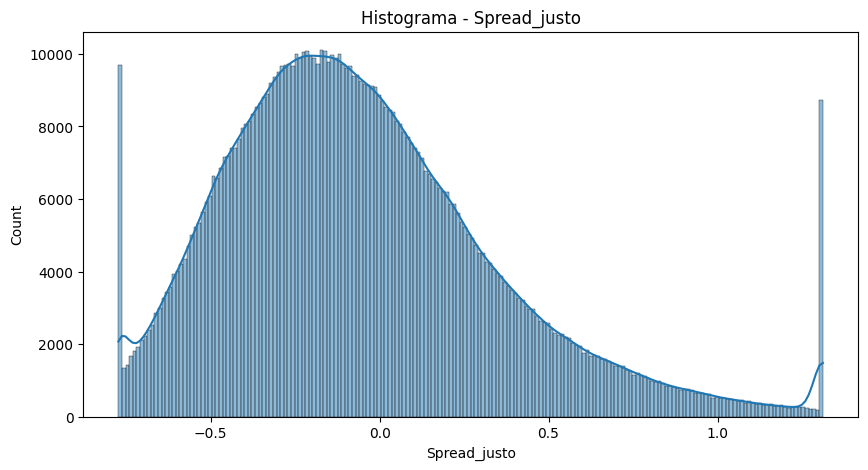

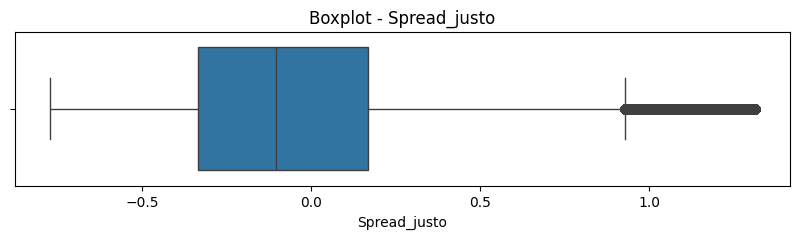

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, jarque_bera

col = "Spread_justo"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [165]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

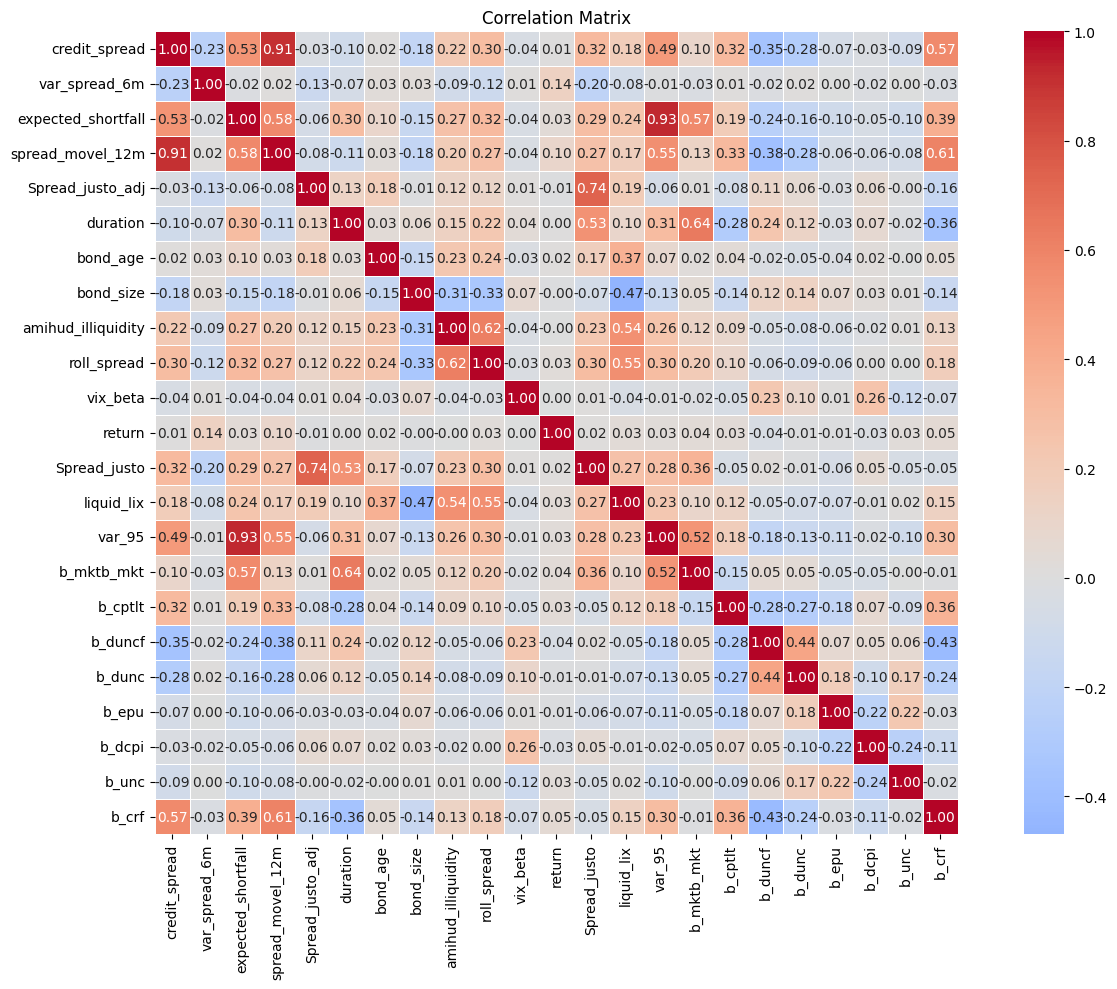

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_model[cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,      # mostra os valores
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [184]:
df_model.isna().sum()

bond_id                0
issuer_id              0
date                   0
credit_spread          0
Spread_justo_adj       0
amihud_illiquidity     0
var_spread_6m          0
return                 0
vix_beta               0
industry_ff30          0
bond_age               0
bond_size              0
vol_diaria             0
duration               0
liquid_lix             0
expected_shortfall     0
var_95                 0
roll_spread            0
b_mktb_mkt             0
b_cptlt                0
b_duncf                0
b_dunc                 0
b_epu                  0
b_dcpi                 0
b_unc                  0
b_crf                  0
spread_movel_12m      35
Spread_justo           0
dtype: int64

In [130]:
!pip install linearmodels
from linearmodels.panel import PanelOLS




[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [204]:
import statsmodels.api as sm

y = df_model["Spread_justo_adj"]

X = df_model[
    [
        "expected_shortfall",
        "duration",
        "bond_age",
        "bond_size",
        "roll_spread",
        "vix_beta",
        "return",
        "liquid_lix",
        "b_mktb_mkt",
        "b_cptlt",
        "b_duncf",
        "b_dunc",
        "b_epu",
        "b_dcpi",
        "b_unc",
        "b_crf"
    ]
]

# Remover observações com NA
dados = pd.concat([y, X], axis=1).dropna()

y = dados["Spread_justo_adj"]
X = dados.drop(columns=["Spread_justo_adj"])

# Constante
X = sm.add_constant(X)

# Regressão OLS
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:       Spread_justo_adj   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     6298.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:37:36   Log-Likelihood:            -1.3254e+05
No. Observations:              852634   AIC:                         2.651e+05
Df Residuals:                  852617   BIC:                         2.653e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0674      0

In [196]:
df_panel = df_model.copy()

df_panel["date"] = pd.to_datetime(df_panel["date"])

df_panel = df_panel.set_index(
    ["issuer_id", "date"]
)

In [207]:
y = df_panel["credit_spread"]

X = df_panel[
    [
        "expected_shortfall",
        "duration",
        "bond_age",
        "bond_size",
        "roll_spread",
        "vix_beta",
        "return",
        "liquid_lix",
        "b_mktb_mkt",
        "b_cptlt",
        "b_duncf",
        "b_dunc",
        "b_epu",
        "b_dcpi",
        "b_crf"
    ]
]

y.isna().sum()
X.isna().sum()

expected_shortfall    0
duration              0
bond_age              0
bond_size             0
roll_spread           0
vix_beta              0
return                0
liquid_lix            0
b_mktb_mkt            0
b_cptlt               0
b_duncf               0
b_dunc                0
b_epu                 0
b_dcpi                0
b_crf                 0
dtype: int64

In [208]:
fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_res = fe_model.fit(
    cov_type="clustered",
    cluster_entity=True,
    low_memory=True
)

print(fe_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          credit_spread   R-squared:                        0.2450
Estimator:                   PanelOLS   R-squared (Between):              0.2544
No. Observations:              852634   R-squared (Within):               0.2165
Date:                Sun, Jun 07 2026   R-squared (Overall):              0.3060
Time:                        23:42:50   Log-likelihood                 2.767e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.836e+04
Entities:                        3823   P-value                           0.0000
Avg Obs:                       223.03   Distribution:               F(15,848617)
Min Obs:                       1.0000                                           
Max Obs:                       9433.0   F-statistic (robust):             276.64
                            

In [206]:
fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_res = fe_model.fit(
    cov_type="clustered",
    cluster_entity=True,
    low_memory=True
)

print(fe_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           Spread_justo   R-squared:                        0.4050
Estimator:                   PanelOLS   R-squared (Between):             -0.1977
No. Observations:              852634   R-squared (Within):               0.4004
Date:                Sun, Jun 07 2026   R-squared (Overall):             -0.3229
Time:                        23:39:00   Log-likelihood                -4.867e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                    3.85e+04
Entities:                        3823   P-value                           0.0000
Avg Obs:                       223.03   Distribution:               F(15,848617)
Min Obs:                       1.0000                                           
Max Obs:                       9433.0   F-statistic (robust):             236.23
                            

In [191]:
from linearmodels.panel import RandomEffects

re_model = RandomEffects(
    y,
    X
)

re_res = re_model.fit()

print(re_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:           Spread_justo   R-squared:                        0.1268
Estimator:              RandomEffects   R-squared (Between):              0.1477
No. Observations:              852634   R-squared (Within):               0.1261
Date:                Sun, Jun 07 2026   R-squared (Overall):              0.1179
Time:                        23:18:59   Log-likelihood                 7.413e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   1.032e+04
Entities:                       22739   P-value                           0.0000
Avg Obs:                       37.497   Distribution:               F(12,852622)
Min Obs:                       1.0000                                           
Max Obs:                       180.00   F-statistic (robust):          1.032e+04
                            

In [192]:
from scipy import stats
import numpy as np

b = fe_res.params
B = re_res.params

common_coef = b.index.intersection(B.index)

b = b[common_coef]
B = B[common_coef]

Vb = fe_res.cov.loc[common_coef, common_coef]
VB = re_res.cov.loc[common_coef, common_coef]

diff = b - B

stat = np.dot(
    np.dot(diff.T, np.linalg.inv(Vb - VB)),
    diff
)

df_h = len(diff)

pval = 1 - stats.chi2.cdf(stat, df_h)

print("Hausman Statistic:", stat)
print("p-value:", pval)

Hausman Statistic: 1626.4873782904308
p-value: 0.0


In [ ]:
df_model.dtypes

bond_id                     category
issuer_id                   category
date                          object
credit_spread                float32
expected_shortfall           float64
sp_rating                      int32
maturity                     float32
duration                     float32
convexity                    float32
callable                        int8
bond_age                     float32
bond_size                    float32
amihud_illiquidity           float32
relative_spread              float64
roll_spread                  float32
vix_beta                     float64
signal_date           datetime64[ns]
signal_gap                   float64
industry_ff17                   Int8
mdc_rating                     int32
dtype: object